In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 30)

In [3]:
df = pd.read_csv(r"C:\Users\HP\Desktop\car data.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nFirst 5 rows:")
display(df.head())

print("\nPrice statistics:")
display(df.describe()[['Selling_Price']])  

Shape: (301, 9)

Columns:
 ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data types:
 Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Price statistics:


,Selling_Price
count,301.000000
mean,4.661296
std,5.082812
min,0.100000
25%,0.900000
50%,3.600000
75%,6.000000
max,35.000000


In [13]:
target = 'Selling_Price'              

categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']  
numerical_features   = ['Present_Price', 'Year', 'Kms_Driven'] 



X = df.drop(columns=[target])
y = df[target]

# First split: 80% train + 20% temp
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Then split the 20% temp → 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # half of 20% → 10%
    random_state=42
)

print(f"Train size : {len(X_train_full):4d}  ({len(X_train_full)/len(df):.1%})")
print(f"Val   size : {len(X_val):4d}      ({len(X_val)/len(df):.1%})")
print(f"Test  size : {len(X_test):4d}      ({len(X_test)/len(df):.1%})")

Train size :  240  (79.7%)
Val   size :   30      (10.0%)
Test  size :   31      (10.3%)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',  StandardScaler(), numerical_features),
        ('cat',  OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'   
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit on train
model_pipeline.fit(X_train_full, y_train_full)

# Predict on val & test
y_val_pred   = model_pipeline.predict(X_val)
y_test_pred  = model_pipeline.predict(X_test)

# Evaluation function
def evaluate(y_true, y_pred, dataset_name=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"─── {dataset_name} ───")
    print(f"MAE :  {mae:,.0f}")
    print(f"RMSE:  {rmse:,.0f}")
    print(f"R²  :  {r2:.4f}\n")

evaluate(y_val,  y_val_pred,  "Validation")
evaluate(y_test, y_test_pred, "Test")

─── Validation ───
MAE :  1
RMSE:  1
R²  :  0.9186

─── Test ───
MAE :  1
RMSE:  1
R²  :  0.9711



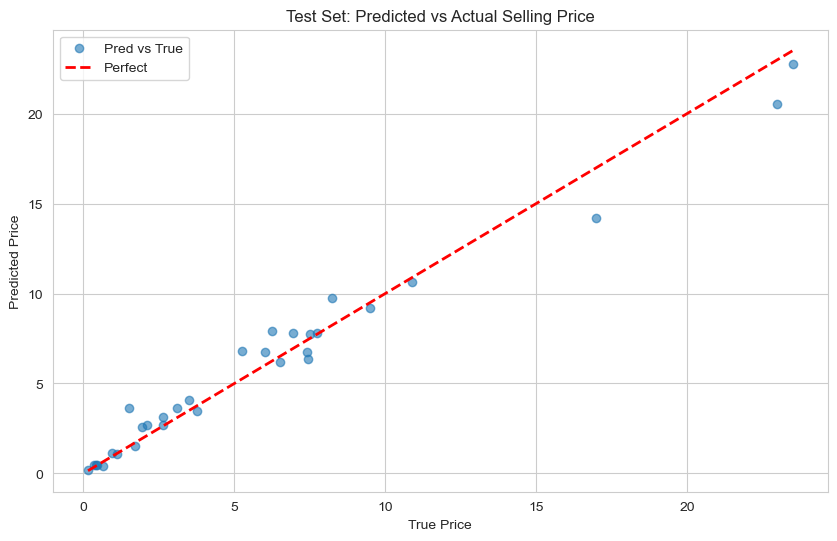

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, label="Pred vs True")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Test Set: Predicted vs Actual Selling Price")
plt.legend()
plt.show()
